# 🖼️ Segmentação de Imagens com CLIPSeg
**Modelo:** `CIDAS/clipseg-rd64-refined`  
**Fonte das imagens:** pasta `./imagens`

Este notebook realiza segmentação semântica **zero-shot** baseada em texto.  
Basta fornecer prompts em linguagem natural e o modelo destaca as regiões correspondentes em cada imagem.

## 📦 1. Instalação das dependências

Instale com `uv` antes de abrir o notebook:
```bash
uv add torch torchvision transformers Pillow matplotlib numpy
```

Ou, se preferir instalar direto na célula abaixo:

In [1]:
# Descomente se precisar instalar no ambiente do notebook
# !pip install torch torchvision transformers Pillow matplotlib numpy -q

## 📚 2. Importações

In [3]:
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation
from PIL import Image
import matplotlib.pyplot as plt
import os
import numpy as np
import torch

# Carregando o modelo e o processador

model_name = "CIDAS/clipseg-rd64-refined"
processor = CLIPSegProcessor.from_pretrained(model_name)
model = CLIPSegForImageSegmentation.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

print(f"Modelo carregado no: {device}")

Loading weights: 100%|██████████| 462/462 [00:00<00:00, 4686.77it/s]
CLIPSegForImageSegmentation LOAD REPORT from: CIDAS/clipseg-rd64-refined
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
clip.vision_model.embeddings.position_ids | UNEXPECTED |  | 
clip.text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo carregado no: cpu


## ⚙️ Processamento das Imagnes
Vamos mapear as imagens da pasta `imagens` com alguns prompts de exemplo para ver a segmentação funcionando


🔍 Processando: birds.png  |  prompts: ['birds', 'branch']


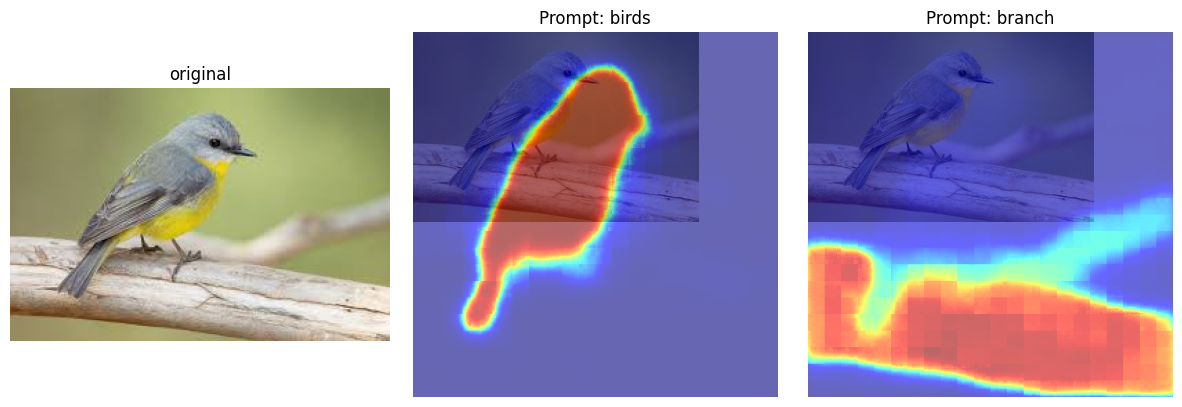


🔍 Processando: cats_dogs.png  |  prompts: ['cat', 'dog', 'bed']


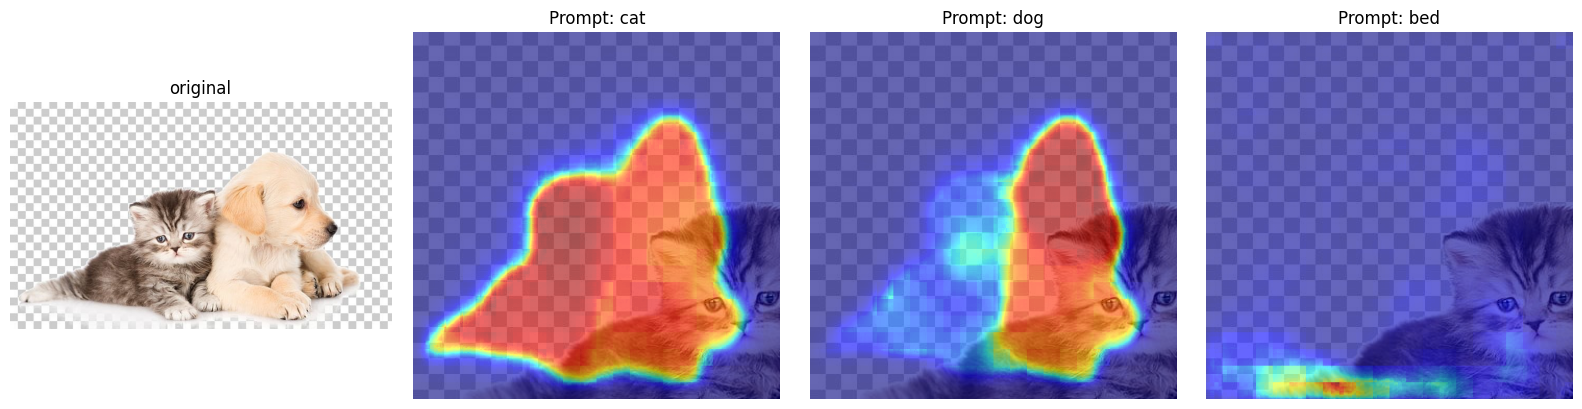


🔍 Processando: kitchen.png  |  prompts: ['cabinet', 'countertop', 'sink', 'stove', 'refrigerator', 'garlic', 'spoon']


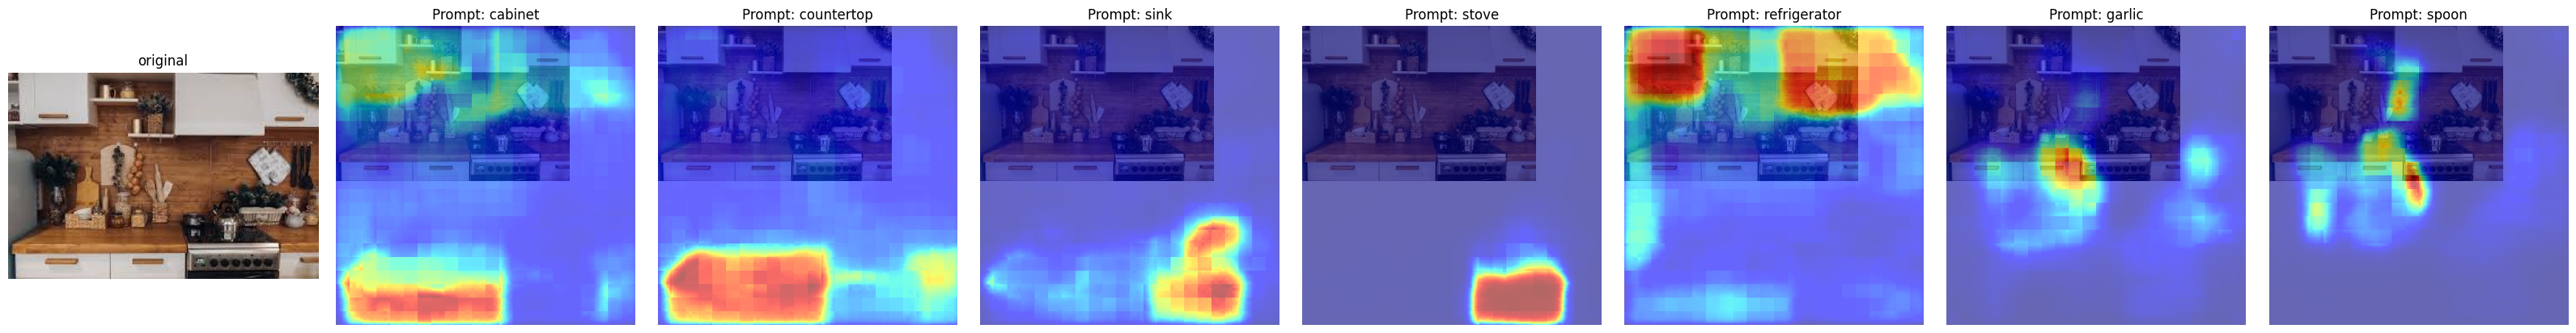


🔍 Processando: pizza.png  |  prompts: ['pizza slice', 'pepperoni', 'cheese', 'pizza', 'table']


c:\Users\Rodrigo\OneDrive\Área de Trabalho\NLW Operators\Visao_Python\.venv\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


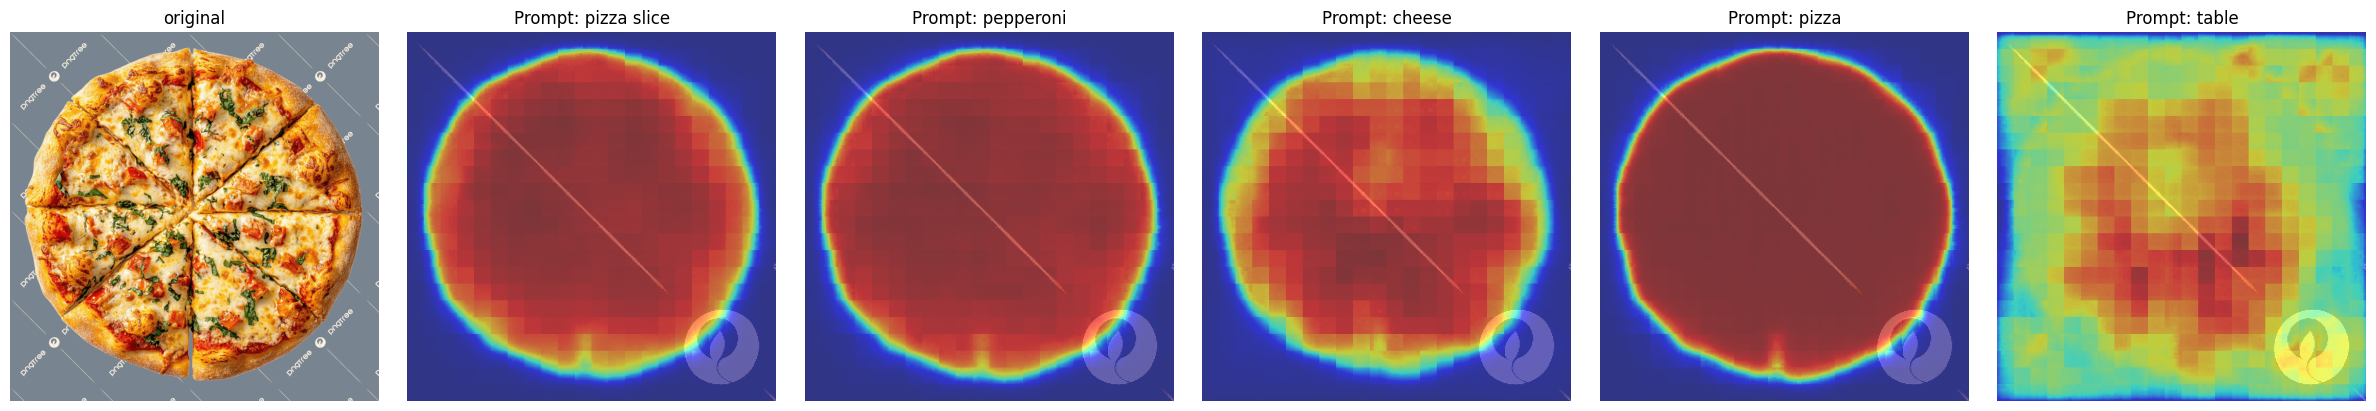

In [4]:
imagens_dir = "imagens"

imagens_and_prompts = {
    "birds.png":     ["birds", "branch"],
    "cats_dogs.png": ["cat", "dog", "bed"],
    "kitchen.png":   ["cabinet", "countertop", "sink", "stove", "refrigerator", "garlic", "spoon"],
    "pizza.png":     ["pizza slice", "pepperoni", "cheese", "pizza", "table"],
}


def segment_image(imagens_path, prompts):
    """Abre a imagem e retorna (image, preds) onde preds tem shape (N_prompts, H, W)."""
    image = Image.open(imagens_path).convert("RGB")

    inputs = processor(
        text=prompts,
        images=[image] * len(prompts),
        padding="max_length",
        return_tensors="pt",
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        preds = torch.sigmoid(outputs.logits)

    return image, preds


def plot_results(image, preds, prompts):
    """Plota a imagem original ao lado das máscaras de cada prompt."""
    n = len(prompts)
    fig, ax = plt.subplots(1, n + 1, figsize=((n + 1) * 4, 4))

    ax[0].imshow(image)
    ax[0].set_title("original")
    ax[0].axis("off")

    for i, prompt in enumerate(prompts):
        mask = preds[i].cpu().numpy()
        ax[i + 1].imshow(image)
        ax[i + 1].imshow(mask, alpha=0.6, cmap="jet")
        ax[i + 1].set_title(f"Prompt: {prompt}")
        ax[i + 1].axis("off")

    plt.tight_layout()
    plt.show()


for filename, prompts in imagens_and_prompts.items():
    path = os.path.join(imagens_dir, filename)

    if not os.path.exists(path):
        print(f"⚠️  Arquivo não encontrado: {path}")
        continue

    print(f"\n🔍 Processando: {filename}  |  prompts: {prompts}")
    image, preds = segment_image(path, prompts)
    plot_results(image, preds, prompts)

## 🤖 4. Carregamento do Modelo

In [ ]:
for img_name, prompts in imagens_and_prompts.items():
    path = os.path.join(imagens_dir, img_name)
    if os.path.exists(path):
        print(f"Processando: {img_name}...")
        img, prediction = segment_image(path, prompts)
        plot_results(img, prediction, prompts)
    else:
        print(f"Aviso: {img_name} não encontrado em {imagens_dir}.")

Aviso: birds.png não encontrado em ./imagens.
Aviso: cats_dogs.png não encontrado em ./imagens.
Aviso: kitchen.png não encontrado em ./imagens.
Aviso: pizza.png não encontrado em ./imagens.


In [ ]:
import os 
print(os.getcwd())

c:\Users\Rodrigo\Downloads


````markdown
## 💡 Como funciona?

O modelo ClipSeg usa o **CLIP** para alinhar as representações visuais e textuais. Ele recebe um prompt (ex: "pizza") e gera um mapa de ativação que destaca os pixels que mais se assemelham a esse conceito.

- **Escalabilidade**: Diferente de modelos clássicos como Mask R-CNN que precisam de classes fixas, o ClipSeg pode segmentar qualquer coisa que o CLIP conheça.
- **Flexibilidade**: Você pode usá-lo para encontrar objetos específicos em cenas complexas apenas variando o texto.
````